## Lista de Exercícios da Disciplina Aprendizagem de Máquina

Professor: Dr. Leandro Carlos de Souza 

Alunos:
* Thiago Ney Evaristo Rodrigues
* Villeneve de Oliveira Soares

### Importações

In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz

from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    adjusted_rand_score,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

import tensorflow as tf
from tensorflow import keras

random_state = 42

### Etapa 1 - Geração dos dados

Gere dois conjuntos de dados correspondentes a duas classes hipotéticas, seguindo distribuições normais bivariadas independentes:

* Classe 1:
$\mu _x = 25$, $\mu _y = 10$, $\sigma _x ^2 = 100$, $\sigma _y ^2 = 25$ e $N = 150 \ \text{Elementos}$

* Classe 2:
$\mu _x = 60$, $\mu _y = 30$, $\sigma _x ^2 = 36$, $\sigma _y ^2 = 144$ e $N = 150 \ \text{Elementos}$

Combine ambas as classes em um único conjunto de 300 pontos.

In [29]:
np.random.seed(random_state)

n_samples = 150

mu_zero = [25, 10]
cov_zero = [[100, 0], [0, 25]]

mu_one = [60, 30]
cov_one = [[36, 0], [0, 144]] 

class_zero = np.random.multivariate_normal(mu_zero, cov_zero, n_samples)
df_zero = pd.DataFrame(class_zero, columns=["x", "y"])
df_zero["class"] = 0

class_one = np.random.multivariate_normal(mu_one, cov_one, n_samples)
df_one = pd.DataFrame(class_one, columns=["x", "y"])
df_one["class"] = 1

df = pd.concat((df_zero, df_one))
display(df)

data = df[["x", "y"]].values
class_true = df["class"].values

,x,y,class
0,29.967142,9.308678,0
1,31.476885,17.615149,0
2,22.658466,8.829315,0
3,40.792128,13.837174,0
4,20.305256,12.712800,0
...,...,...,...
145,57.134055,30.858795,1
146,62.001973,35.747758,1
147,56.939902,42.450479,1
148,54.127418,26.761501,1


### Etapa 2 - Aplicação do K-means

1. Aplique o algoritmo K-means com $k=2$.
2. Visualize os clusters resultantes, plotando o agrupamento em cores diferentes.
3. Calcule a matriz de confusão.
4. Calcule o índice de Rand ajustado para esse agrupamento.

In [30]:
# Aplicação do Algoritmo k-means

kmeans = KMeans(n_clusters=2, random_state=random_state, n_init="auto")
class_pred = kmeans.fit_predict(df.iloc[:, 0:2])

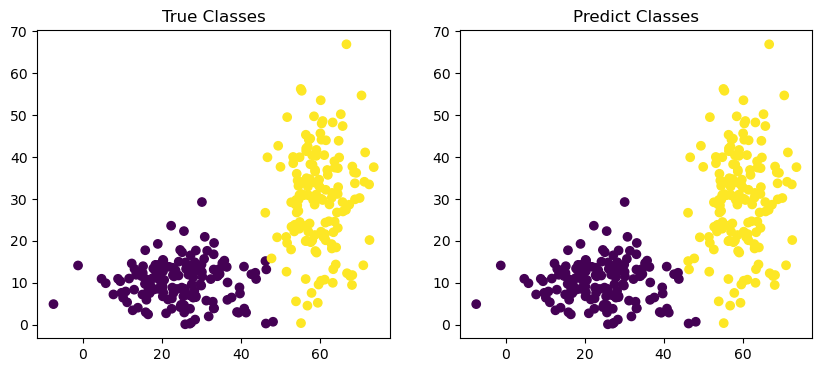

In [31]:
# Plot dos Clusters Resultantes

fig, axs = plt.subplots(1, 2, figsize=(10, 4))
axs[0].scatter(df.loc[:, "x"], df.loc[:, "y"], c=df.loc[:, "class"])
axs[0].set_title("True Classes")
axs[1].scatter(df.loc[:, "x"], df.loc[:, "y"], c=class_pred)
axs[1].set_title("Predict Classes");

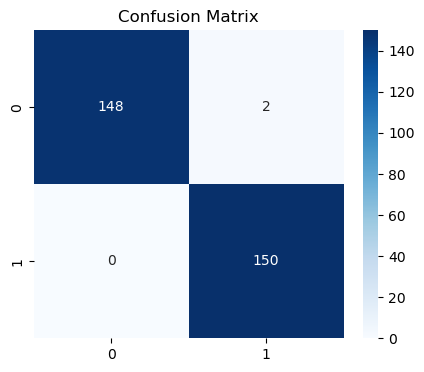

In [32]:
# Plot da Matriz de Confusão

cm = confusion_matrix(class_true, class_pred)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, fmt="d", annot=True, cmap="Blues")
plt.title("Confusion Matrix");

In [33]:
# Métrica de Avaliação

ari = adjusted_rand_score(class_true, class_pred)
print(f"O Índice de Rand Ajustado (ARI) é: {ari:.4f}")

O Índice de Rand Ajustado (ARI) é: 0.9734


### Etapa 3 - Aplicação do Fuzzy C-means

1. Aplique o algoritmo Fuzzy C-means (use $c=2$).
2. Analise os graus de pertinência (membership) de cada ponto a cada cluster.
3. Plote os pontos colorindo-os de acordo com o grau de pertinência à Classe 1 (por exemplo, intensidade da cor → grau de pertencimento).

In [34]:
# Aplicação do Algoritmo Fuzzy C-means

c = 2
cntr, u, u0, d, jm, p, fpc = fuzz.cluster.cmeans(
    data.T, c, m=2.0, error=0.005, maxiter=1000, seed=random_state
)

print(f"Centros dos clusters:\n{cntr}\n")
print(f"Fuzzy Partition Coefficient (FPC): {fpc:.4f}")

Centros dos clusters:
[[59.47418797 30.76989607]
 [24.27498701 10.16440833]]

Fuzzy Partition Coefficient (FPC): 0.8738


In [35]:
# Análise dos Graus de Pertinência para cada Cluster

u_df = pd.DataFrame(u.T, columns=[f"Cluster_{i}" for i in range(c)])
df = df.reset_index(drop=True)
u_df = u_df.reset_index(drop=True)
df = pd.concat([df, u_df], axis=1)

display(df)

,x,y,class,Cluster_0,Cluster_1
0,29.967142,9.308678,0,0.024284,0.975716
1,31.476885,17.615149,0,0.100896,0.899104
2,22.658466,8.829315,0,0.002387,0.997613
3,40.792128,13.837174,0,0.310512,0.689488
4,20.305256,12.712800,0,0.011821,0.988179
...,...,...,...,...,...
295,57.134055,30.858795,1,0.996376,0.003624
296,62.001973,35.747758,1,0.985221,0.014779
297,56.939902,42.450479,1,0.936571,0.063429
298,54.127418,26.761501,1,0.963134,0.036866


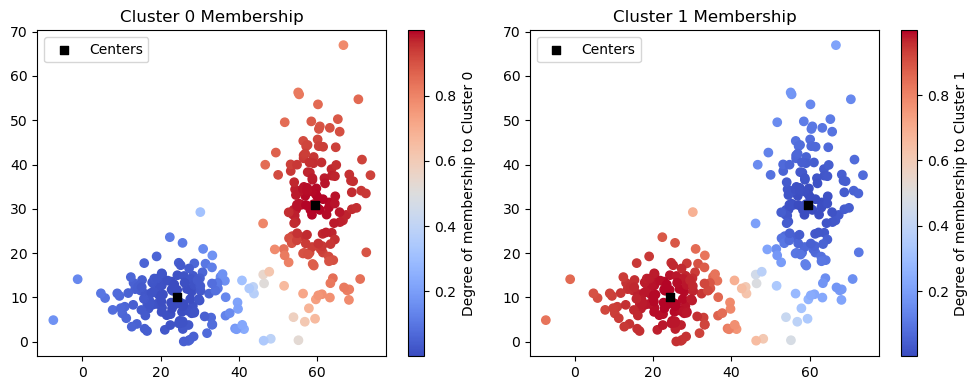

In [36]:
# Plot do Grau de Pertinência para cada Cluster

fig, axs = plt.subplots(1, 2, figsize=(10, 4))

scatter0 = axs[0].scatter(df["x"], df["y"], c=df["Cluster_0"], cmap="coolwarm")
fig.colorbar(scatter0, ax=axs[0], label="Degree of membership to Cluster 0")
axs[0].scatter(cntr[:, 0], cntr[:, 1], marker="s", c="black", label="Centers")
axs[0].set_title("Cluster 0 Membership")
axs[0].legend()

scatter1 = axs[1].scatter(df["x"], df["y"], c=df["Cluster_1"], cmap="coolwarm")
fig.colorbar(scatter1, ax=axs[1], label="Degree of membership to Cluster 1")
axs[1].scatter(cntr[:, 0], cntr[:, 1], marker="s", c="black", label="Centers")
axs[1].set_title("Cluster 1 Membership")
axs[1].legend()

plt.tight_layout()

### Etapa 4 - Aplicação da Regressão Logística

1. Treine um modelo de Regressão Logística para classificar as duas classes verdadeiras.
2. Plote a fronteira de decisão obtida pelo modelo.
3. Calcule as métricas de desempenho (acurácia, precisão, recall, F1-score).

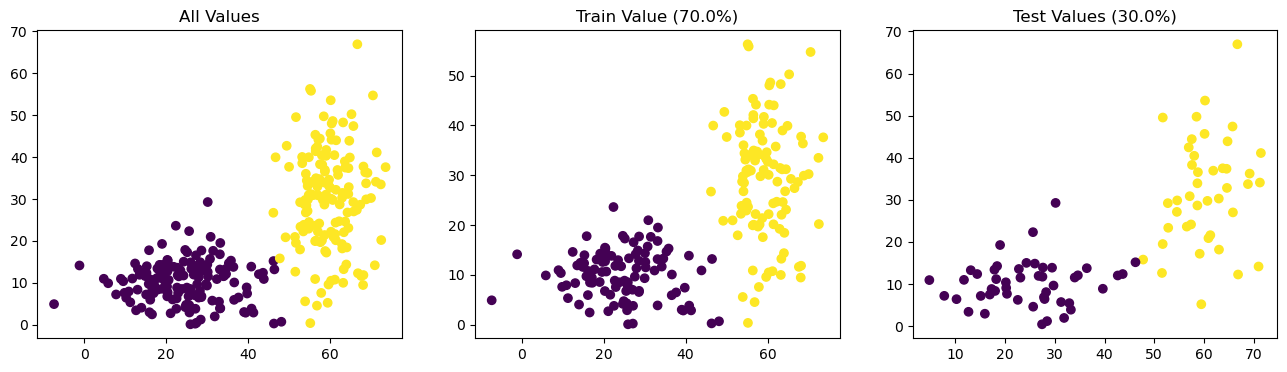

In [37]:
# Divisão dos Dados de Treino e Teste

test_size = 0.3
X_train, X_test, y_train, y_test = train_test_split(
    data, class_true, test_size=test_size, random_state=random_state
)

fig, axs = plt.subplots(1, 3, figsize=(16, 4))
axs[0].scatter(df.loc[:, "x"], df.loc[:, "y"], c=df.loc[:, "class"])
axs[0].set_title("All Values")
axs[1].scatter(X_train[:, 0], X_train[:, 1], c=y_train)
axs[1].set_title(f"Train Value ({(1-test_size)*100}%)")
axs[2].scatter(X_test[:, 0], X_test[:, 1], c=y_test)
axs[2].set_title(f"Test Values ({test_size*100}%)");

In [38]:
# Aplicação do Modelo de Regressão Logística

logistic_model = LogisticRegression(random_state=random_state)
logistic_model.fit(X_train, y_train)

y_pred = logistic_model.predict(X_test)

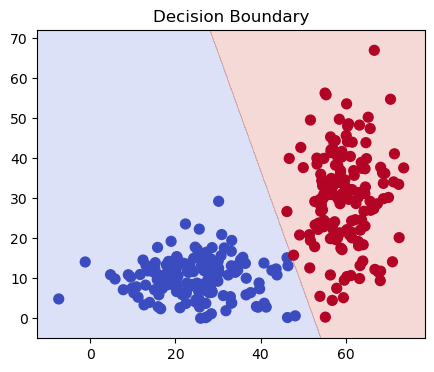

In [39]:
# Plot da Fronteira de Decisão

x_min, x_max = data[:, 0].min() - 5, data[:, 0].max() + 5
y_min, y_max = data[:, 1].min() - 5, data[:, 1].max() + 5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

Z = logistic_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
plt.scatter(df["x"], df["y"], c=df["class"], cmap="coolwarm", s=50)
plt.title("Decision Boundary");

Desempenho do Modelo de Regressão Logística

Acurácia: 1.0000
Precisão: 1.0000
Recall: 1.0000
F1-score: 1.0000


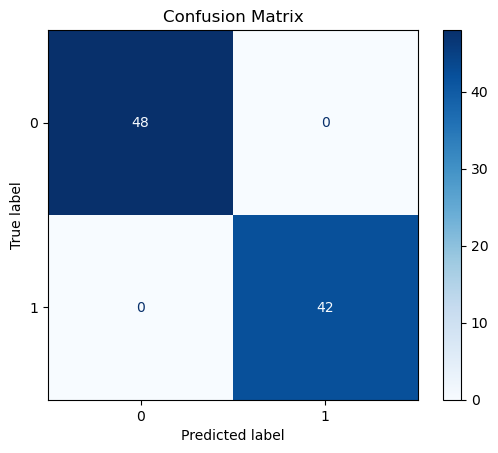

In [40]:
# Métricas de Avaliação

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Desempenho do Modelo de Regressão Logística")
print(f"\nAcurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-score: {f1:.4f}")

ConfusionMatrixDisplay.from_estimator(logistic_model, X_test, y_test, cmap="Blues")
plt.title("Confusion Matrix");

### Etapa 5 - Rede Neural Artificial

1. Crie e treine uma rede neural totalmente conectada (feedforward)
2. Plote a fronteira de decisão da RNA e compare com a da Regressão Logística.
3. Calcule as métricas de desempenho (acurácia, precisão, recall, F1-score).

In [41]:
gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    print("Nenhuma GPU encontrada. O teste da GPU será pulado.")
else:
    print(f"Encontrada(s) {len(gpus)} GPU(s).")

Encontrada(s) 1 GPU(s).


In [42]:
num_classes = 2

input_ = keras.layers.Input(shape=X_train.shape[1:])

hidden1 = keras.layers.Dense(64, activation="relu")(input_)
hidden2 = keras.layers.Dense(128, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(64, activation="relu")(hidden2)

output = keras.layers.Dense(1, activation="sigmoid")(hidden3)

mlp_model = keras.Model(inputs=[input_], outputs=[output])

custom_optimizer = keras.optimizers.Adam(learning_rate=0.001)
mlp_model.compile(
    loss="binary_crossentropy", optimizer=custom_optimizer, metrics=["accuracy"]
)
mlp_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 2)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,833 (65.75 KB)

 Trainable params: 16,833 (65.75 KB)

 Non-trainable params: 0 (0.00 B)

In [43]:
history = mlp_model.fit(
    X_train,
    y_train,
    epochs=150,
    batch_size=32,
    validation_data=(X_test, y_test),
    verbose=1,
)

Epoch 1/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 110ms/step - accuracy: 0.5190 - loss: 0.8690 - val_accuracy: 0.4667 - val_loss: 0.7495
Epoch 2/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5714 - loss: 0.6327 - val_accuracy: 0.5111 - val_loss: 0.6101
Epoch 3/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.5524 - loss: 0.5775 - val_accuracy: 0.5889 - val_loss: 0.5580
Epoch 4/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.6286 - loss: 0.5485 - val_accuracy: 0.5111 - val_loss: 0.5779
Epoch 5/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6095 - loss: 0.5317 - val_accuracy: 0.7889 - val_loss: 0.5698
Epoch 6/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5952 - loss: 0.5608 - val_accuracy: 0.6778 - val_loss: 0.5252
Epoch 7/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6667 - loss: 0.5461 - val_accuracy: 0.6556 - val_loss: 0.5095
Epoch 8/150
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6857 - loss: 0.5328 - val_accuracy: 0.5556 - val_loss

Acurácia no Teste: 98.89%


<Figure size 640x480 with 0 Axes>

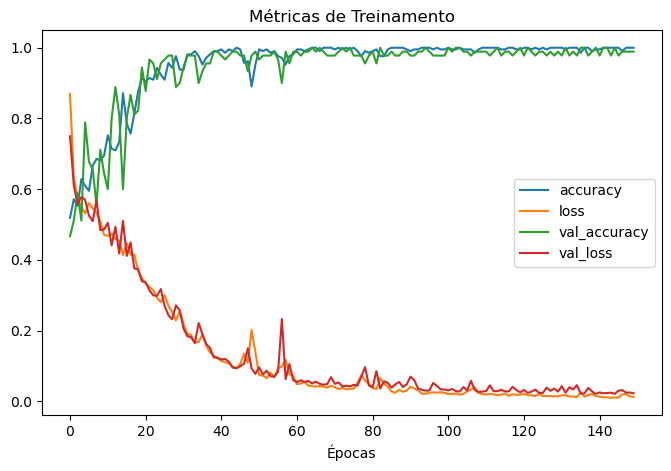

In [44]:
loss, accuracy = mlp_model.evaluate(X_test, y_test, verbose=0)
print(f"Acurácia no Teste: {accuracy * 100:.2f}%")

plt.figure()
pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.title("Métricas de Treinamento")
plt.xlabel("Épocas");

31250/31250 ━━━━━━━━━━━━━━━━━━━━ 25s 792us/step


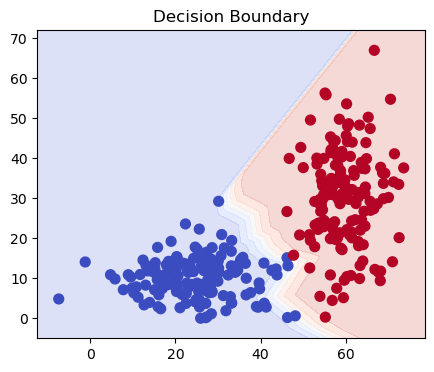

In [45]:
# Plot da Fronteira de Decisão

x_min, x_max = data[:, 0].min() - 5, data[:, 0].max() + 5
y_min, y_max = data[:, 1].min() - 5, data[:, 1].max() + 5

xx, yy = np.meshgrid(np.linspace(x_min, x_max, 1000), np.linspace(y_min, y_max, 1000))

Z = mlp_model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(5, 4))
plt.contourf(xx, yy, Z, alpha=0.2, cmap="coolwarm")
plt.scatter(df["x"], df["y"], c=df["class"], cmap="coolwarm", s=50)
plt.title("Decision Boundary");

### Etapa 6 - Máquina de Vetores de Suporte (SVM)

1. Treine um modelo de SVM.
2. Plote a fronteira de decisão obtida pelo SVM.
3. Calcule as métricas de desempenho (acurácia, precisão, recall, F1-score).

### Etapa 7 - Árvore de Decisão

1. Treine uma Árvore de Decisão para classificar as duas classes.
2. Visualize a árvore e a fronteira de decisão no espaço.
3. Avalie métricas de desempenho: acurácia, precisão, recall, F1-score.

### Etapa 8 - K-Vizinhos Mais Próximos (KNN)

1. Treine um modelo KNN usando os dados de treino.
2. Plote a fronteira de decisão para cada $k$.
3. Compare métricas de desempenho (acurácia, precisão, recall, F1-score) com os outros
modelos.
